In [1]:
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np
import matplotlib.pyplot as plt
import scipy

def std(x):return unp.std_devs(x)
def nom(x):return unp.nominal_values(x)
def arrayu_to_uarray(x):
    return unp.uarray([a.nominal_value for a in x],[a.std_dev for a in x])

def sigma(u1,u2):
    return abs(u1.nominal_value - u2.nominal_value)/np.sqrt(u1.std_dev ** 2 + u2.std_dev ** 2)

/usr/lib/python3.14/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_components (with no parentheses).
  return float(sqrt(sum(delta**2 for delta in self.error_components().values())))
/usr/lib/python3.14/site-packages/uncertainties/core.py:491: FutureWarning: AffineScalarFunc.derivatives() is deprecated. It will be removed in a future release.
  for variable, derivative in self.derivatives.items():
/usr/lib/python3.14/site-packages/uncertainties/unumpy/core.py:84: FutureWarning: the uncertainties.unumpy.unumpy_to_numpy_matrix function is deprecated. It will be removed in a future release.
  warn(msg, FutureWarning)


Abgelesener Nullpunkt: -268.2+/-1.3


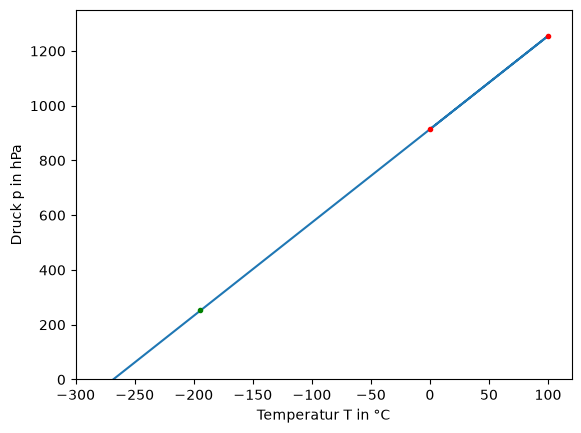

In [2]:
P_raum = ufloat(1007.8,0.1)
P_normal = 1013.25
Eich_Druck_1 = arrayu_to_uarray([ufloat(914,1),ufloat(1248,1) * P_normal/P_raum])


Eich_Temp_1 = [0,100]

plt.errorbar(Eich_Temp_1,nom(Eich_Druck_1), yerr=std(Eich_Druck_1),fmt="r.")

intercept  = Eich_Temp_1[0] - Eich_Druck_1[0] * (Eich_Temp_1[1] - Eich_Temp_1[0]) / (Eich_Druck_1[1] - Eich_Druck_1[0])
print("Abgelesener Nullpunkt:" ,intercept)
plt.plot(Eich_Temp_1 + [intercept.nominal_value], list(nom(Eich_Druck_1)) + [0])
plt.xlim(-300,120)
#plt.xlim(-200,-180)
plt.ylim(0,1350)
#plt.ylim(200,300)


P_N = 255  # Stickstoff
T_N_abgelesen = -194.4
plt.errorbar([T_N_abgelesen], [P_N],fmt="g.")

plt.xlabel("Temperatur T in °C")
plt.ylabel("Druck p in hPa")
plt.savefig("zwei_eichpunkte.svg")

Abgelesener Nullpunkt: 0.04431194761343704
Temp Trockeneis -73.35+/-0.30


/usr/lib/python3.14/site-packages/uncertainties/unumpy/core.py:84: FutureWarning: the uncertainties.unumpy.unumpy_to_numpy_matrix function is deprecated. It will be removed in a future release.
  warn(msg, FutureWarning)
/usr/lib/python3.14/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_components (with no parentheses).
  return float(sqrt(sum(delta**2 for delta in self.error_components().values())))
/usr/lib/python3.14/site-packages/uncertainties/core.py:491: FutureWarning: AffineScalarFunc.derivatives() is deprecated. It will be removed in a future release.
  for variable, derivative in self.derivatives.items():


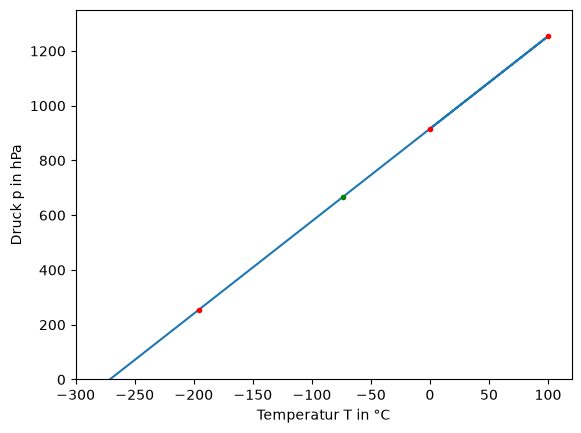

In [3]:
# Eichkurve mit drei Punkten


P_raum = ufloat(1007.8,0.1)
P_normal = 1013.25
Eich_Druck_1 = arrayu_to_uarray([ufloat(914,1),ufloat(1248,1) * P_normal/P_raum,ufloat(255,1)])


Eich_Temp_1 = np.array([0,100,-195.8])

plt.errorbar(Eich_Temp_1,nom(Eich_Druck_1), yerr=std(Eich_Druck_1),fmt="r.")

def linear_func(x, a, b): return a*x + b

fit, error_fit = scipy.optimize.curve_fit(linear_func,Eich_Temp_1, nom(Eich_Druck_1))

x = np.append(Eich_Temp_1,-273)

plt.plot(x,linear_func(x,fit[0],fit[1]))

T_0_abgelesen = -271.1 # Abgelesener Nullpunkt
print("Abgelesener Nullpunkt:" , linear_func(T_0_abgelesen,fit[0],fit[1]))

plt.xlim(-300,120)
#plt.xlim(-200,-180)
plt.ylim(0,1350)
#plt.ylim(200,300)

# Druck = a * Temp + b
# Temp = (Druck - b) / a
a = ufloat(fit[0], np.sqrt(np.diag(error_fit))[0])
b = ufloat(fit[1], np.sqrt(np.diag(error_fit))[1])

def Druck_zu_Temp(p):
    return (p - fit[1]) / fit[0]

P_Trockeneis = ufloat(668,1)
print("Temp Trockeneis", Druck_zu_Temp(P_Trockeneis))
plt.errorbar( [Druck_zu_Temp(P_Trockeneis.nominal_value)],[P_Trockeneis.nominal_value], fmt="g.")

plt.xlabel("Temperatur T in °C")
plt.ylabel("Druck p in hPa")

plt.savefig("drei_eichpunkte.svg")


Abgelesener Nullpunkt: -922.6187105001943
Temp Trockeneis 199.80+/-0.30


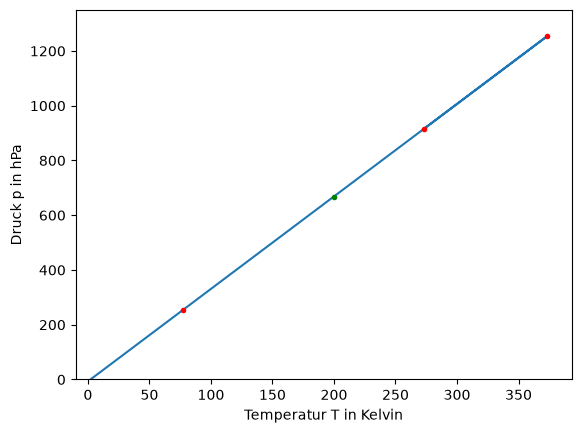

In [10]:
# Eichkurve mit drei Punkten

T_kelvin = 273.15
P_raum = ufloat(1007.8,0.1)
P_normal = 1013.25
Eich_Druck_1 = arrayu_to_uarray([ufloat(914,1),ufloat(1248,1) * P_normal/P_raum,ufloat(255,1)])


Eich_Temp_1 = np.array([0,100,-195.8]) + T_kelvin

plt.errorbar(Eich_Temp_1,nom(Eich_Druck_1), yerr=std(Eich_Druck_1),fmt="r.")

def linear_func(x, a, b): return a*x + b

fit, error_fit = scipy.optimize.curve_fit(linear_func,Eich_Temp_1, nom(Eich_Druck_1))

x = np.append(Eich_Temp_1,-273)

plt.plot(x,linear_func(x,fit[0],fit[1]))

T_0_abgelesen = -271.1 # Abgelesener Nullpunkt
print("Abgelesener Nullpunkt:" , linear_func(T_0_abgelesen,fit[0],fit[1]))

plt.xlim(-10,120 + T_kelvin)
#plt.xlim(-200,-180)
plt.ylim(0,1350)
#plt.ylim(200,300)

# Druck = a * Temp + b
# Temp = (Druck - b) / a
a = ufloat(fit[0], np.sqrt(np.diag(error_fit))[0])
b = ufloat(fit[1], np.sqrt(np.diag(error_fit))[1])

def Druck_zu_Temp(p):
    return (p - fit[1]) / fit[0]

P_Trockeneis = ufloat(668,1)
print("Temp Trockeneis", Druck_zu_Temp(P_Trockeneis))
plt.errorbar( [Druck_zu_Temp(P_Trockeneis.nominal_value)],[P_Trockeneis.nominal_value], fmt="g.")

plt.xlabel("Temperatur T in Kelvin")
plt.ylabel("Druck p in hPa")

plt.savefig("drei_eichpunkte_kelvin.svg")



In [12]:
Wasser = [ # (Spannung, Druck, Temperatur (Pyrometer)
    (100.2,914,0),
    (104,946,10),
    (108,985,20.5),
    (111.7,1016,29),
    (115.7,1053,38.1),
    (119.7,1086,48.8),
    (123.4,1117,56),
    (127,1147,64.7),
    (130.7,1180,73.4),
    (134.5,1213,79.6),
    (138.4,1248,90.6)
]

Spannung = arrayu_to_uarray([ufloat(w[0], 0.005 * w[0] + 0.2) for w in Wasser]) * 1e-3 # in V
Druck = arrayu_to_uarray([ufloat(w[1],1) for w in Wasser])
T_pyro = arrayu_to_uarray([ufloat(w[2], 0.015 * w[2] + 2) for w in Wasser]) # TODO stimmt der Fehler von 2 grad???


def printu(u):
    return str(u).replace("/","")


In [15]:
T_gas = Druck_zu_Temp(Druck) - 273.15# Temperatur des Gastermometers

print("\n".join(f'num("{printu(a)}"), num("{printu(b)}"),' for a,b in zip(Druck, Druck_zu_Temp(Druck) - 273.15)))

num("914.0+-1.0"), num("-0.53+-0.30"),
num("946.0+-1.0"), num("8.95+-0.30"),
num("985.0+-1.0"), num("20.49+-0.30"),
num("1016.0+-1.0"), num("29.67+-0.30"),
num("1053.0+-1.0"), num("40.62+-0.30"),
num("1086.0+-1.0"), num("50.39+-0.30"),
num("1117.0+-1.0"), num("59.57+-0.30"),
num("1147.0+-1.0"), num("68.45+-0.30"),
num("1180.0+-1.0"), num("78.22+-0.30"),
num("1213.0+-1.0"), num("87.99+-0.30"),
num("1248.0+-1.0"), num("98.35+-0.30"),


/tmp/ipykernel_43380/2063463519.py:1: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  I_mess = ufloat(0.001,0) # TOOD Fehler # Messtrom in A
/usr/lib/python3.14/site-packages/uncertainties/unumpy/core.py:84: FutureWarning: the uncertainties.unumpy.unumpy_to_numpy_matrix function is deprecated. It will be removed in a future release.
  warn(msg, FutureWarning)
/tmp/ipykernel_43380/2063463519.py:17: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  print("Sigma_Abweichung Steigung", sigma(slope, ufloat(A,0))) # TODO interpretieren


Steigung:  0.388+/-0.008
Sigma_Abweichung Steigung 0.4010389107728774


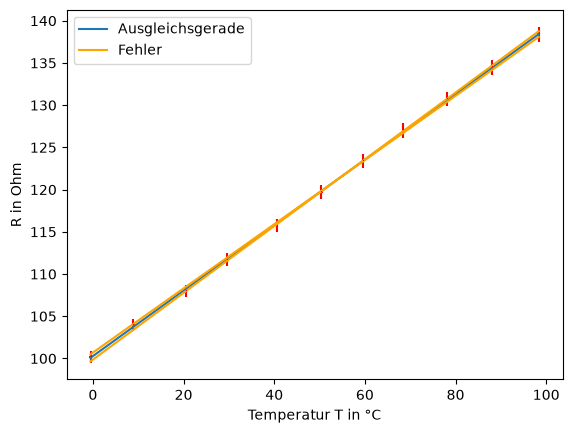

In [16]:
I_mess = ufloat(0.001,0) # TOOD Fehler # Messtrom in A

R = Spannung / I_mess

plt.errorbar(nom(T_gas), nom(R), xerr=std(T_gas),yerr=std(R), fmt ="r,")

ptfit, pterror = scipy.optimize.curve_fit(linear_func, nom(T_gas),nom(R),sigma=std(R),absolute_sigma=True)

plt.plot(nom(T_gas), linear_func(nom(T_gas),ptfit[0],ptfit[1]), label="Ausgleichsgerade")



pterror = np.sqrt(np.diag(pterror))
slope = ufloat(ptfit[0],pterror[0])
print("Steigung: ", slope) 
A = 3.9083 * 1e-3 * 100 # Faktor 100 weil R_0 = 100 Ohm
print("Sigma_Abweichung Steigung", sigma(slope, ufloat(A,0))) # TODO interpretieren 

###############



plt.plot(nom(T_gas), linear_func(nom(T_gas),ptfit[0] + pterror[0],ptfit[1] - pterror[1]),color="orange", label="Fehler")
plt.plot(nom(T_gas), linear_func(nom(T_gas),ptfit[0] - pterror[0] ,ptfit[1] + pterror[1]), color="orange")

plt.legend()
plt.xlabel("Temperatur T in °C")
plt.ylabel("R in Ohm")

plt.savefig("Widerstand_zu_Temp.svg")

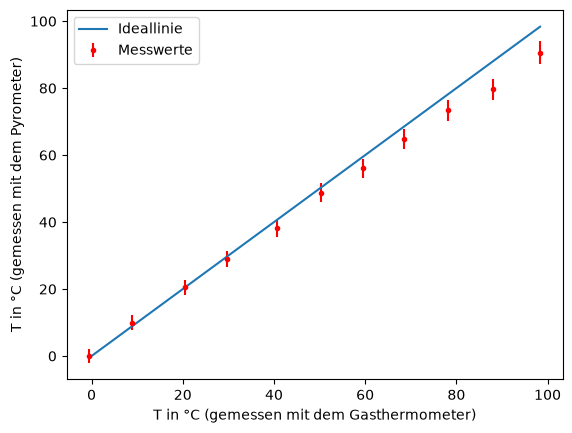

In [17]:

plt.errorbar(nom(T_gas), nom(T_gas), label="Ideallinie")
plt.errorbar(nom(T_gas), nom(T_pyro),yerr=std(T_pyro), fmt="r.", label="Messwerte")
plt.xlabel("T in °C (gemessen mit dem Gasthermometer)")
plt.ylabel("T in °C (gemessen mit dem Pyrometer)")

plt.legend()
plt.savefig("pyrometer.svg")
# Mögliche erklärungen: - Oberflächentemperatur kleiner
# - Wasserdampf kühler
# - 